# SENTINEL-WM  |  Phase 3-6 - Baselines, World Model, Simulation, Explainability

* **Phase 3** - Logistic Regression + Random Forest on the *current window only*
  (no temporal modelling by construction) -> the comparison floor.
* **Phase 4** - `SentinelWorldModel`: elapsed-time Temporal Transformer encoder
  + probabilistic State-Transition Network + attack head + progression head.
* **Phase 5** - K-step Monte-Carlo forward simulation -> P(attack) timeline +
  ATT&CK phase per horizon step.
* **Phase 6** - SHAP / gradient x input feature attribution + attention saliency.

In [1]:
# bootstrap: make the sentinel_wm package importable without pip install
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / 'sentinel_wm').is_dir() else _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

In [2]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sentinel_wm import config as C, baselines as B, train as WT, evaluate as EV
from sentinel_wm import forward_sim as FS, explain as EX
device = C.resolve_device('auto'); device

'cuda'

## 3.1  Baselines

In [3]:
base = B.run_baselines(verbose=True)

[baseline] train=1800 val=575 test=594 F=41 K=6


[logistic_regression] any-k F1=0.752 P=0.837 R=0.683 FPR=0.034 AUROC=0.921 (n=594, pos=120)
           MLT=10.0s  detect=0.14  FA=0.032


[random_forest] any-k  F1=0.815 P=0.945 R=0.717 FPR=0.011 AUROC=0.974 (n=594, pos=120)
           MLT=0.0s  detect=0.00  FA=0.008
[baseline] metrics -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\baselines\baseline_metrics.json


## 3.2  Train the world model
40 epochs is ~10 s on GPU / ~1 min on CPU for the single-day dataset.
Early-stops on `val F1 + 0.5*prog_acc`; freezes the alert threshold on val to
hit FPR <= 5%, then evaluates the untouched test split.

In [4]:
import argparse
ns = argparse.Namespace(test=False, epochs=40, batch_size=None, lr=None, device=device)
report = WT.train(C.CONFIG, ns)

[train] device=cuda
[train] features=41 L=10 K=6 | train=1800 val=575 test=594


[train] attack_pos_weight=6.64 prog_w=[0.13 0.8  1.16 0.35 2.56]


  ep001  0.9s L=5.1630 (atk 2.425 prog 3.270 next 1.103) | val F1=0.106 AUROC=0.598 progAcc=0.618 MLT=10s


  ep002  0.3s L=4.7449 (atk 2.328 prog 2.920 next 0.957) | val F1=0.169 AUROC=0.694 progAcc=0.797 MLT=10s


  ep003  0.3s L=4.4572 (atk 2.214 prog 2.738 next 0.874) | val F1=0.218 AUROC=0.759 progAcc=0.843 MLT=10s


...

  ep018  0.3s L=1.8626 (atk 0.734 prog 1.559 next 0.349) | val F1=0.603 AUROC=0.849 progAcc=0.873 MLT=47s


  ep019  0.3s L=1.7812 (atk 0.691 prog 1.509 next 0.335) | val F1=0.560 AUROC=0.838 progAcc=0.885 MLT=47s


  ep020  0.3s L=1.7417 (atk 0.673 prog 1.495 next 0.321) | val F1=0.556 AUROC=0.842 progAcc=0.875 MLT=47s


  ep021  0.3s L=1.7027 (atk 0.652 prog 1.469 next 0.316) | val F1=0.560 AUROC=0.829 progAcc=0.891 MLT=47s


  ep022  0.3s L=1.6724 (atk 0.640 prog 1.467 next 0.298) | val F1=0.560 AUROC=0.830 progAcc=0.893 MLT=47s
[train] early stop at epoch 22

================  WORLD MODEL - TEST  ================
any-horizon            F1=0.800 P=0.784 R=0.817 FPR=0.057 AUROC=0.949 (n=594, pos=120)
  k  horizon     F1   prec    rec    FPR  AUROC  Brier
  1     10s   0.796  0.711  0.905  0.070  0.960  0.060
  2     20s   0.776  0.697  0.876  0.074  0.956  0.068
  3     30s   0.758  0.692  0.838  0.075  0.949  0.072
  4     40s   0.755  0.708  0.808  0.067  0.947  0.069
  5     50s   0.745  0.705  0.790  0.067  0.929  0.075
  6     60s   0.725  0.675  0.782  0.077  0.927  0.088
progression acc (all k) : 0.887   k=1 : 0.912
Mean Lead Time          : 30.0 s  (median 25s, max 60s)
episodes warned         : 4/7 (0.57)   false-alarm rate 0.046
Brier(k1) 0.060   ECE(k1) 0.083   alert threshold 0.55

[train] checkpoint -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\world_model.pt


## 3.3  Benchmark - world model vs baselines
The world model is not meant to beat a tree ensemble on *nowcast* F1 for a
sustained flood - it is meant to win on **lead time** and to **hold F1 as the
forecast horizon grows**. Read the `Mean Lead Time` and per-horizon columns.

In [5]:
bench = EV.benchmark(verbose=True)

# SENTINEL-WM Benchmark

## Any-horizon classification + forecasting

| Model | F1 | Precision | Recall | FPR | AUROC | Mean Lead Time (s) | Detection | FA rate | Brier(k1) | ECE(k1) |
|---|---|---|---|---|---|---|---|---|---|---|
| logistic_regression | 0.752 | 0.837 | 0.683 | 0.034 | 0.921 | 10.0 | 0.14 | 0.032 | 0.077 | 0.094 |
| random_forest | 0.815 | 0.945 | 0.717 | 0.011 | 0.974 | 0.0 | 0.00 | 0.008 | 0.035 | 0.042 |
| persistence | 0.836 | 0.957 | 0.742 | 0.008 | 0.867 | 0.0 | 0.00 | 0.000 | - | - |
| SENTINEL-WM | 0.800 | 0.784 | 0.817 | 0.057 | 0.949 | 30.0 | 0.57 | 0.046 | 0.060 | 0.083 |

## Forecast-horizon accuracy (F1 vs lead time)

| k (horizon) | SENTINEL-WM F1 | LogReg F1 | RandForest F1 |
|---|---|---|---|
| +10s | 0.796 | 0.777 | 0.900 |
| +20s | 0.776 | 0.804 | 0.890 |
| +30s | 0.758 | 0.781 | 0.876 |
| +40s | 0.755 | 0.798 | 0.857 |
| +50s | 0.745 | 0.766 | 0.831 |
| +60s | 0.725 | 0.754 | 0.822 |

World-model progression-state accuracy (test): **0.887**
World-mod

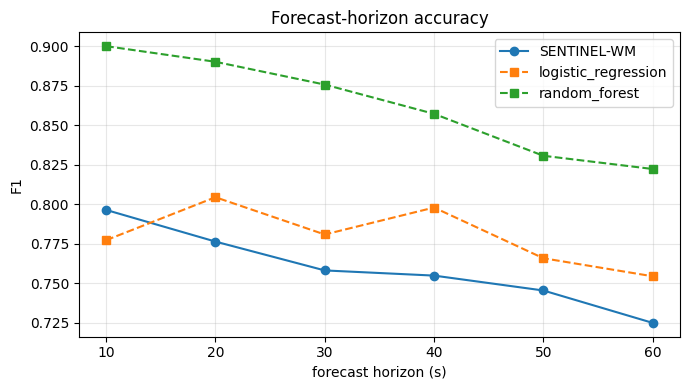

In [6]:
wm = report['test']['per_horizon']
plt.figure(figsize=(7,4))
plt.plot([r['horizon_seconds'] for r in wm], [r['f1'] for r in wm], 'o-', label='SENTINEL-WM')
for name in ['logistic_regression','random_forest']:
    ph = base[name]['per_horizon']
    plt.plot([r['horizon_seconds'] for r in ph], [r['f1'] for r in ph], 's--', label=name)
plt.xlabel('forecast horizon (s)'); plt.ylabel('F1'); plt.legend(); plt.grid(alpha=.3)
plt.title('Forecast-horizon accuracy'); plt.tight_layout()

## 3.4  Calibration - reliability diagram (k=1)

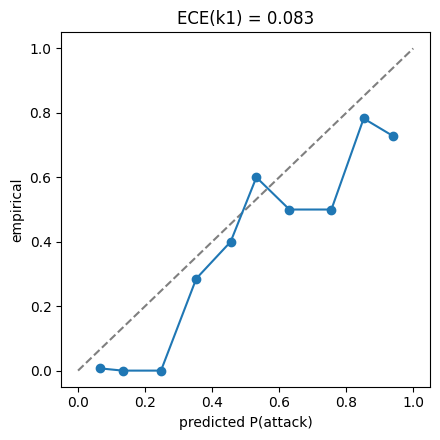

In [7]:
rb = report['test']['reliability']
conf = [b['conf'] for b in rb if b['n']]; acc = [b['acc'] for b in rb if b['n']]
plt.figure(figsize=(4.5,4.5)); plt.plot([0,1],[0,1],'k--',alpha=.5)
plt.plot(conf, acc, 'o-'); plt.xlabel('predicted P(attack)'); plt.ylabel('empirical')
plt.title(f"ECE(k1) = {report['test']['ece_k1']:.3f}"); plt.tight_layout()

## 3.5  Forward simulation - one attack anchor
P(attack) per horizon step with 95% CI, predicted progression state, and the
ATT&CK phase + confidence that `attack_stages.assess_forecast` assigns.

In [8]:
res = FS.simulate_split('test', limit=250, device=device, with_explain=True)
atk = [r for r in res if r['meta']['y_now']==1]
r = atk[len(atk)//2]
for h in r['horizon']:
    a = h['attck']
    print(f"+{h['horizon_seconds']:>3}s  P={h['attack_prob']:.2f} "
          f"CI[{h['attack_ci'][0]:.2f},{h['attack_ci'][1]:.2f}]  "
          f"{h['progression_state']:<12} {a['kill_chain_phase']:<20} {a['confidence']}")

+ 10s  P=0.68 CI[0.57,0.80]  ACTIVE       Impact               Medium
+ 20s  P=0.55 CI[0.39,0.72]  NORMAL       None                 Medium
+ 30s  P=0.49 CI[0.30,0.66]  NORMAL       None                 Medium
+ 40s  P=0.44 CI[0.26,0.63]  NORMAL       None                 Low
+ 50s  P=0.41 CI[0.24,0.60]  NORMAL       None                 Low
+ 60s  P=0.40 CI[0.20,0.58]  NORMAL       None                 Low


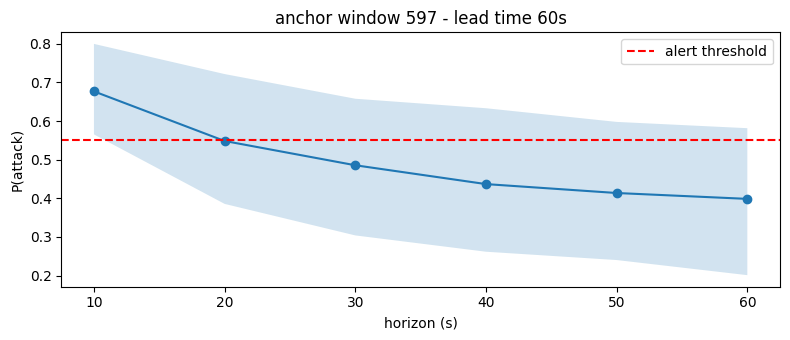

In [9]:
hz = r['horizon']; ks = [h['horizon_seconds'] for h in hz]
plt.figure(figsize=(8,3.5))
plt.plot(ks, [h['attack_prob'] for h in hz], 'o-')
plt.fill_between(ks, [h['attack_ci'][0] for h in hz], [h['attack_ci'][1] for h in hz], alpha=.2)
plt.axhline(r['alert_threshold'], color='r', ls='--', label='alert threshold')
plt.xlabel('horizon (s)'); plt.ylabel('P(attack)'); plt.legend()
plt.title(f"anchor window {r['meta']['window_index']} - lead time {r['lead_time_seconds']}s")
plt.tight_layout()

## 3.6  Explainability - what is driving the prediction

[explain] shap_installed=False
[explain] world-model top features:
    rst_rate                   0.2397
    byte_rate                  0.0829
    byte_count                 0.0716
    syn_rate                   0.0700
    ack_rate                   0.0399
    retransmission_rate        0.0388
    port_scan_max_run          0.0362
    packet_rate                0.0359
[explain] -> C:\Users\chall\OneDrive\Desktop\SIH\artifacts\reports\explainability.json


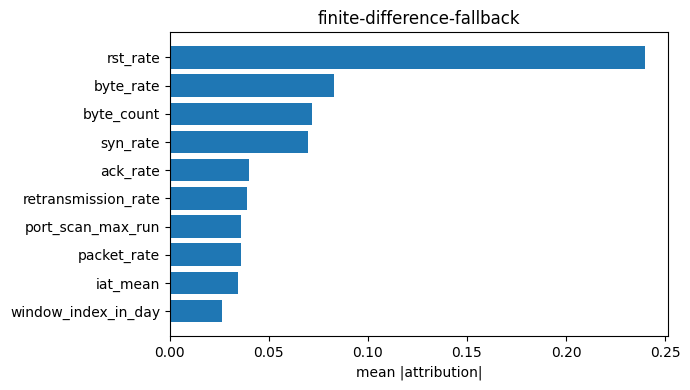

In [10]:
full = EX.run_all(device)
tf = full['world_model_shap']['top_features'][:10]
plt.figure(figsize=(7,4))
plt.barh([t['feature'] for t in tf][::-1], [t['mean_abs_shap'] for t in tf][::-1])
plt.xlabel('mean |attribution|'); plt.title(full['world_model_shap']['method'])
plt.tight_layout()

In [11]:
dfck = r['driving_features']
print('per-history-window attention saliency:')
print(np.round(dfck['temporal_saliency_attention'], 3))
print('\ntop features for this anchor:')
for t in dfck['top_features'][:6]: print(f"  {t['feature']:24s} {t['importance']:.3f}")

per-history-window attention saliency:
[0.304 0.169 0.146 0.098 0.085 0.08  0.042 0.037 0.021 0.017]

top features for this anchor:
  syn_rate                 0.160
  port_scan_max_run        0.084
  rst_rate                 0.053
  flow_duration_mean       0.052
  fwd_bwd_ratio            0.051
  flow_count               0.051


---
Artifacts written: `artifacts/world_model.pt`, `artifacts/reports/benchmark.md`,
`world_model_metrics.json`, `forward_sim*.json`, `explainability.json`.

CLI equivalent of this whole notebook:  `python cli.py all`